# GA-BO-TR — Part 3: Strong Baselines, BBOB-24, Engineering, Statistics

This notebook runs the full experimental campaign for the paper:

1. **Strong baselines** — HEBO (JAIR 2022), TuRBO-1 (NeurIPS 2019),
   CMA-ES (Hansen), Optuna-TPE, Random.
2. **BBOB-24 sweep** — all 24 noiseless BBOB functions × 3 instances ×
   d ∈ {5, 10, 20} via `ioh`, 15 seeds (216 settings × 6 methods).
3. **Engineering design** with proper constrained BO — Welded Beam,
   Pressure Vessel, Tension Spring, Speed Reducer — compared against the
   naive quadratic-penalty approach as a sanity check.
4. **Mixed-variable HPO** — MLPClassifier hyper-parameter optimisation
   on breast-cancer dataset (4 continuous + 1 categorical).
5. **Statistical protocol** — Friedman + Iman-Davenport + Holm (one-vs-
   control) + Nemenyi all-pairs + critical-difference diagram, via
   `scikit-posthocs`.
6. **Summary tables** and the LaTeX export for the paper.

Run Parts 1 and 2 first (in the same kernel).


d:\GA-BO\venv\Lib\site-packages\nbformat\__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)


Environment ready.
Config done — dtype=double, device= cuda
Registered 10 synthetic functions.
BBOB smoke: BBOB-f01-i1-d5 f(0)=92.304, f*=79.480
GP smoke-test  mu[:5] = [42.783 45.717 54.14  42.713 22.983]
             sigma[:5] = [0.024 0.02  0.023 0.026 0.026]


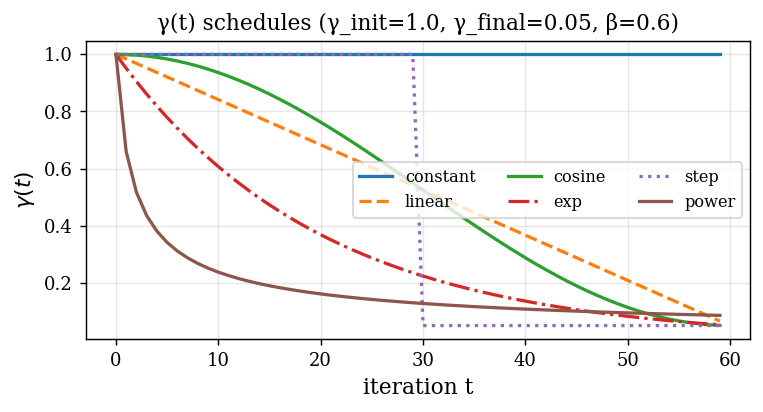

ELA smoke: 37 raw features, summary =
   skewness     = -1.0553
   kurtosis     = +1.2561
   n_peaks      = +2.0000
   h_max        = +0.8975
   eps_s        = +0.0851
   m0           = +0.6379
   nb_fit_cor   = -0.7165
   nn_mean      = +0.8898
   disp_25      = +0.7423
   disp_05      = +0.4525
   pca_expl_x   = +1.0000
GA / DE optimisers defined.
Base BO loops defined: StandardBO, GA_BO, RandomSearch.
StandardBO       final regret =   2.8617   wall =   9.4s
GA-BO(DIV)       final regret =   6.4660   wall =   3.3s
Random           final regret =   5.9122   wall =   0.0s
Part 1 ready.


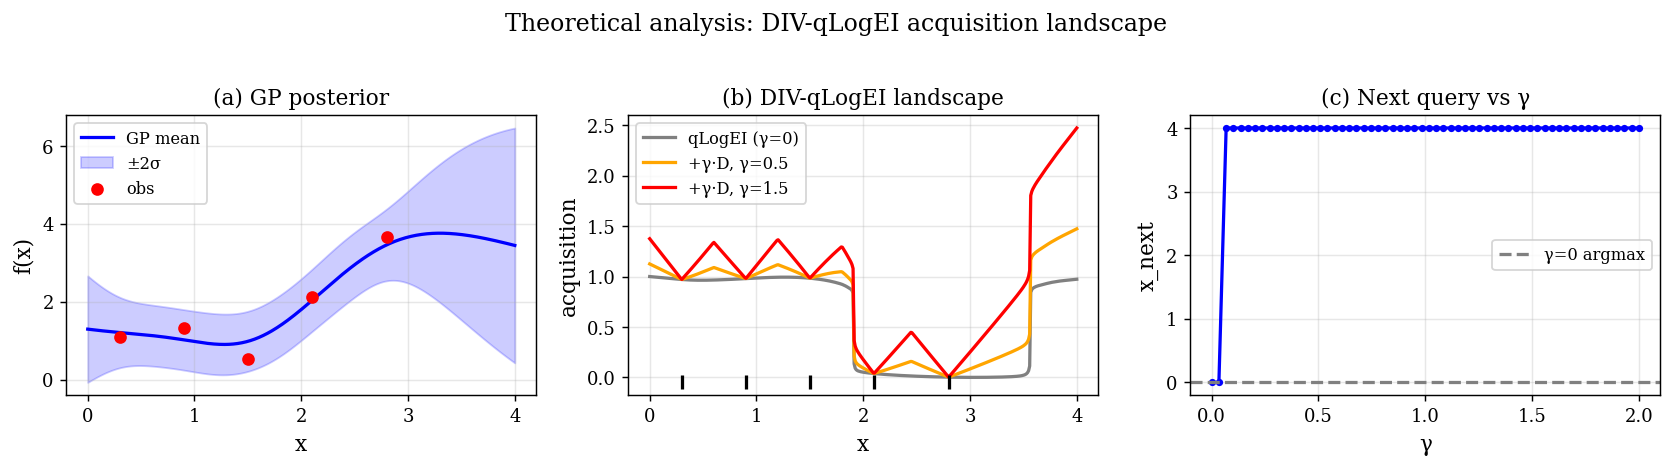

GA_BO_TR defined — the main proposed method.
Loaded cached classifier from results_gabotr/ela_gamma_rf.joblib
Total tasks: 200  (5 methods × 4 functions × 10 seeds)


Running: 100%|██████████| 200/200 [1:07:53<00:00, 20.37s/it]


Saved → results_gabotr/ablation.json


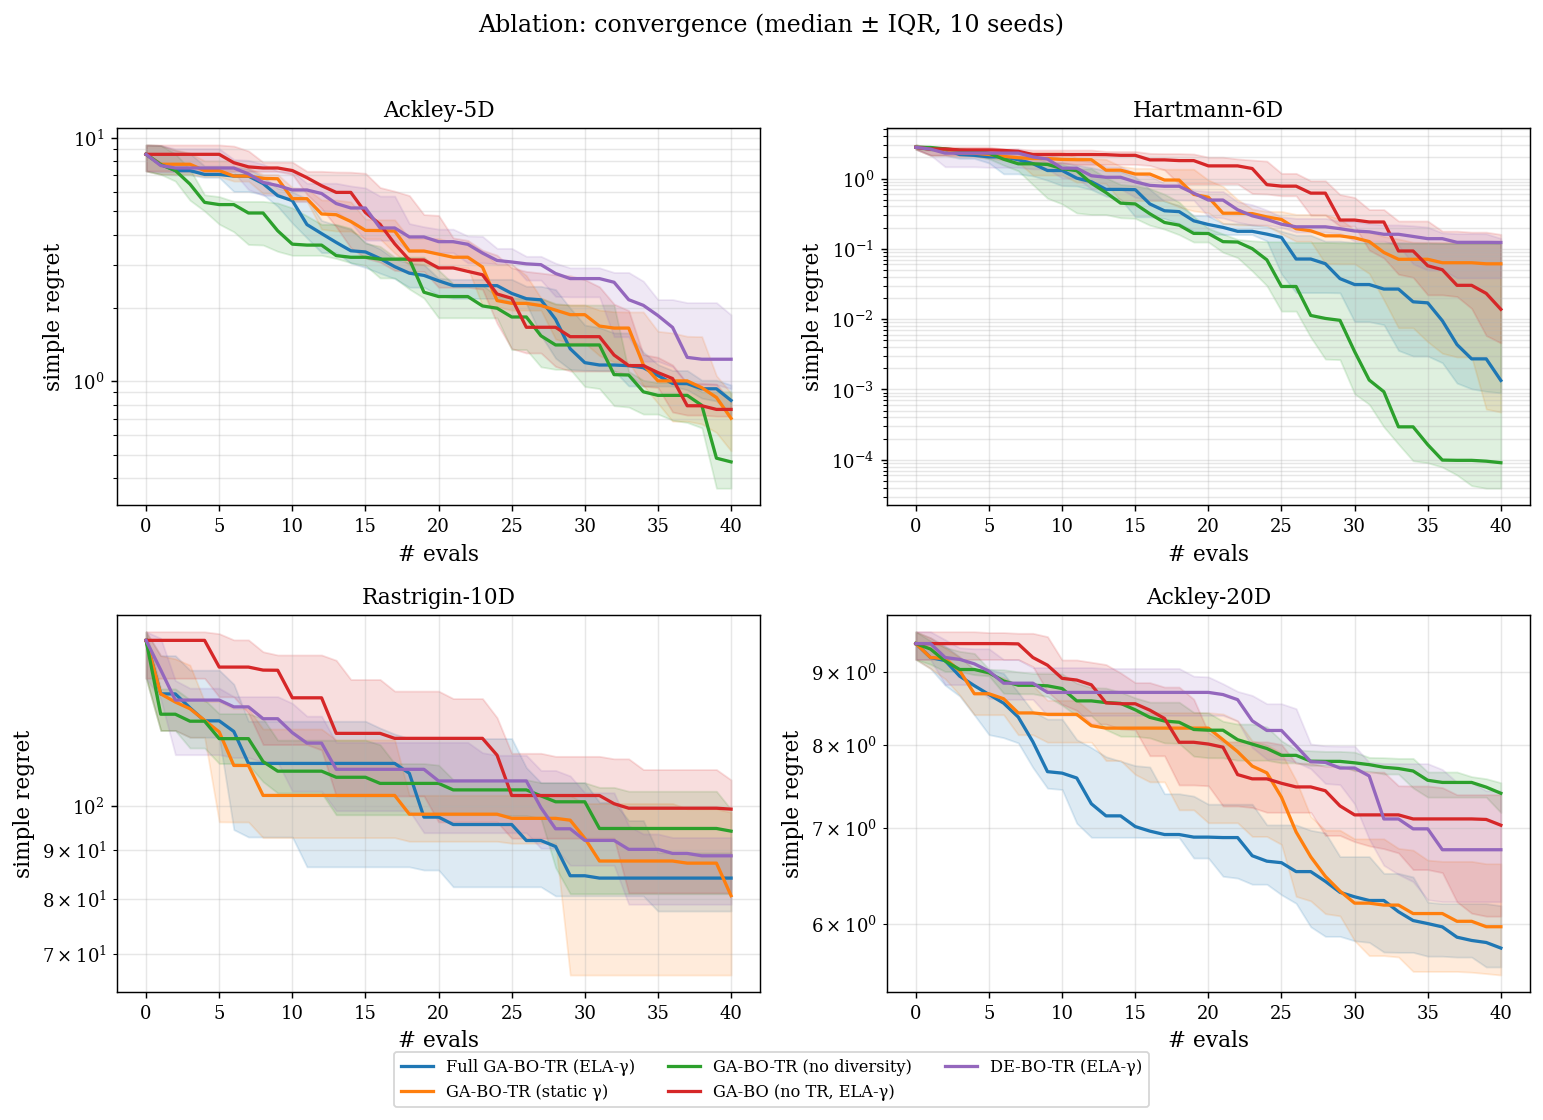

Saved figures_gabotr/ablation_convergence.pdf


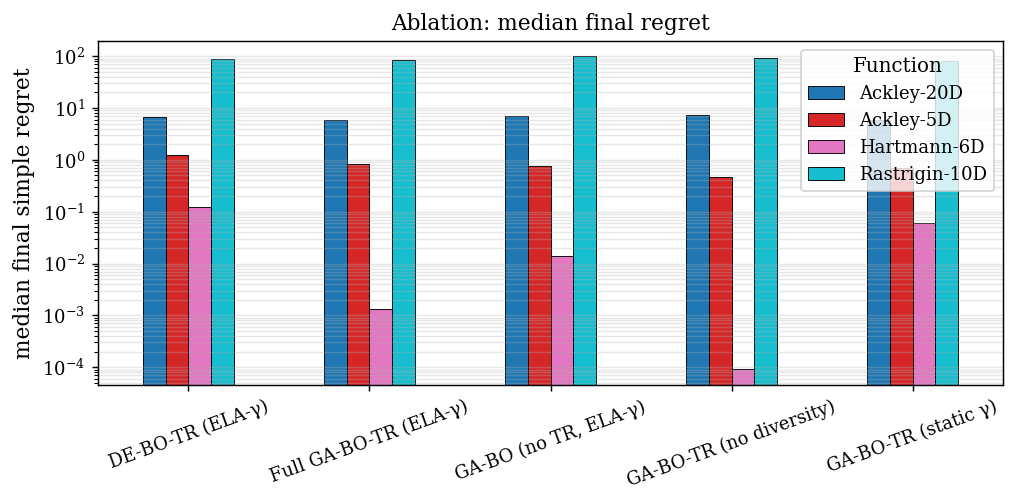

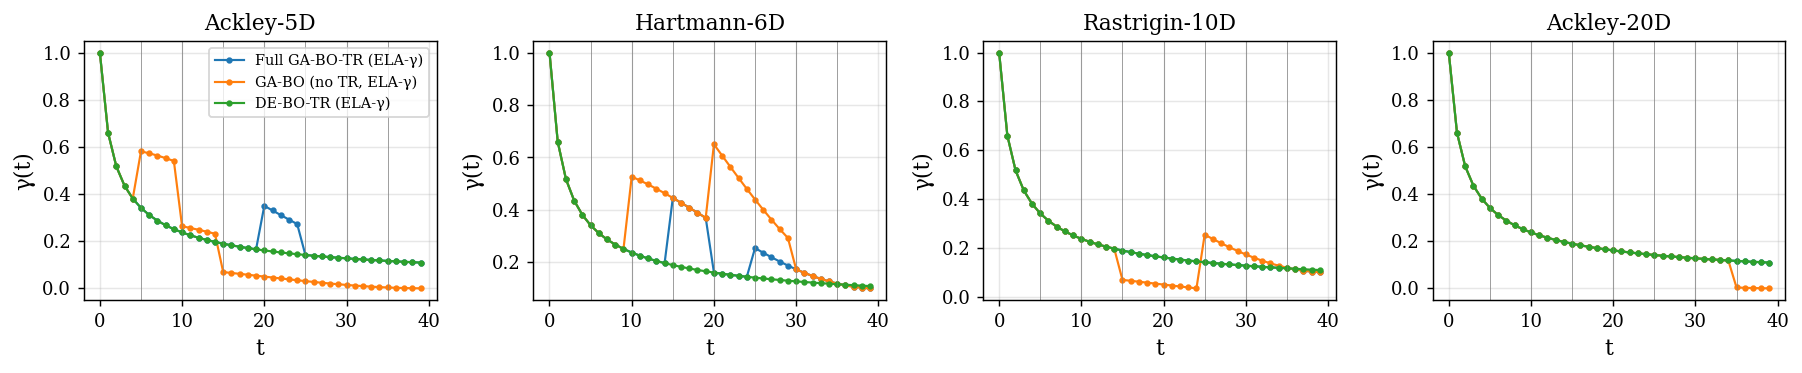

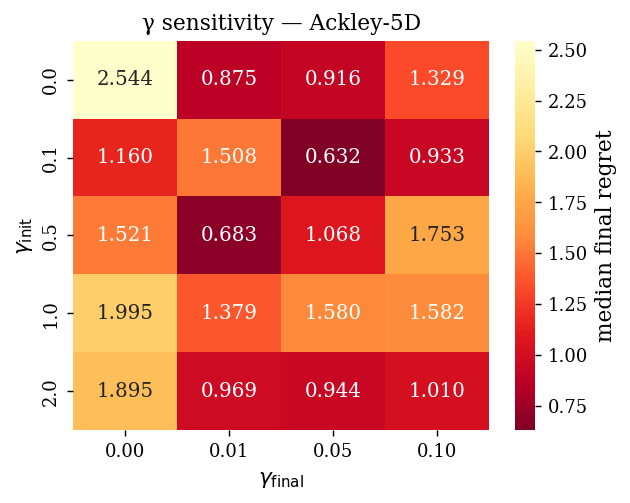

In [1]:
%run GA_BO_TR_Part2.ipynb


## 1. Strong baselines


In [2]:
class CMAESBaseline:
    """CMA-ES (Hansen) wrapped to share the BOResult signature."""
    def __init__(self, bounds, n_init: int = 5, n_iter: int = 50, seed: int = 42, **_):
        self.bounds = bounds; self.d = bounds.shape[0]
        self.n_init = n_init; self.n_iter = n_iter
        self.seed = seed; self.n_total = n_init + n_iter

    def run(self, objective, func_name="unknown", verbose=False) -> BOResult:
        import cma
        t0 = time.time()
        lo, hi = self.bounds[:,0], self.bounds[:,1]
        mid = (lo + hi) / 2; sigma0 = float(np.mean(hi - lo) / 4)
        opts = cma.CMAOptions()
        opts["bounds"] = [lo.tolist(), hi.tolist()]
        opts["maxfevals"] = self.n_total
        opts["verbose"] = -9; opts["seed"] = int(self.seed) + 1
        Xh, yh = [], []
        def wrap(x):
            val = float(objective(np.asarray(x)))
            Xh.append(list(x)); yh.append(val); return val
        try:
            cma.CMAEvolutionStrategy(mid.tolist(), sigma0, opts).optimize(wrap)
        except Exception: pass
        Xh = np.array(Xh[:self.n_total]); yh = np.array(yh[:self.n_total])
        if len(yh) == 0:
            yh = np.array([float(objective(mid))]); Xh = np.array([mid])
        best = [float(np.min(yh[:i+1])) for i in range(len(yh))]
        return BOResult(method="CMA-ES", func_name=func_name,
                        best_values=best, x_history=Xh, y_history=yh,
                        wall_time=time.time()-t0, seed=self.seed)


class OptunaTPEBaseline:
    """Tree-structured Parzen Estimator (Bergstra 2011) via Optuna."""
    def __init__(self, bounds, n_init: int = 5, n_iter: int = 50, seed: int = 42, **_):
        self.bounds = bounds; self.d = bounds.shape[0]
        self.n_init = n_init; self.n_iter = n_iter
        self.seed = seed; self.n_total = n_init + n_iter

    def run(self, objective, func_name="unknown", verbose=False) -> BOResult:
        import optuna
        optuna.logging.set_verbosity(optuna.logging.WARNING)
        t0 = time.time()
        lo, hi = self.bounds[:,0], self.bounds[:,1]
        Xh, yh = [], []
        def obj(trial):
            x = np.array([trial.suggest_float(f"x{j}", float(lo[j]), float(hi[j]))
                          for j in range(self.d)])
            val = float(objective(x))
            Xh.append(x); yh.append(val); return val
        sampler = optuna.samplers.TPESampler(seed=self.seed)
        study = optuna.create_study(direction="minimize", sampler=sampler)
        study.optimize(obj, n_trials=self.n_total, show_progress_bar=False)
        Xh = np.array(Xh); yh = np.array(yh)
        best = [float(np.min(yh[:i+1])) for i in range(len(yh))]
        return BOResult(method="Optuna-TPE", func_name=func_name,
                        best_values=best, x_history=Xh, y_history=yh,
                        wall_time=time.time()-t0, seed=self.seed)


In [3]:
class TuRBO1Baseline:
    """TuRBO-1 baseline: TuRBO state machine + Thompson sampling inside TR."""
    def __init__(self, bounds, n_init: int = 10, n_iter: int = 50,
                 kernel: str = "matern52", seed: int = 42, **_):
        self.bounds = bounds; self.d = bounds.shape[0]
        self.n_init = n_init; self.n_iter = n_iter
        self.kernel = kernel; self.seed = seed
        self.rng = np.random.RandomState(seed)

    def _ts_inside_tr(self, gp, y_obs_np, tr_bounds, n_cand: int) -> np.ndarray:
        """Thompson sampling: sample function values at random TR candidates, pick argmin."""
        lo, hi = tr_bounds[:,0], tr_bounds[:,1]
        X_cand = lo + self.rng.rand(n_cand, self.d) * (hi - lo)
        Xt = torch.as_tensor(X_cand, dtype=DTYPE, device=DEVICE)
        with torch.no_grad():
            post = gp.posterior(Xt)
            samples = post.rsample(torch.Size([1])).squeeze(0)  # (n_cand, 1)
        samples = samples.detach().cpu().numpy().ravel()
        if getattr(gp, "_maximize_flag", False):
            # Internal max → want argmax = min in raw scale
            return X_cand[int(np.argmax(samples))]
        else:
            return X_cand[int(np.argmin(-samples))]   # posterior is on -y internally

    def run(self, objective, func_name="unknown", verbose=False) -> BOResult:
        t0 = time.time()
        X_obs = lhs_sample(self.n_init, self.bounds, self.rng)
        y_obs = np.array([objective(r) for r in X_obs])
        best = [float(y_obs.min())]
        tr_hist: List[float] = []

        state = TurboState(dim=self.d, batch_size=1, length=0.8, success_tolerance=10)
        state.best_value = float(y_obs.min())

        for _ in range(self.n_iter):
            gp = build_gp(X_obs, y_obs, self.bounds, kernel=self.kernel)
            y_best_prev = float(y_obs.min())
            x_center = X_obs[int(np.argmin(y_obs))]
            tr_b = trust_region_bounds(gp, x_center, self.bounds, state.length)
            tr_hist.append(float(state.length))
            x_next = self._ts_inside_tr(gp, y_obs, tr_b, n_cand=min(2000, 200*self.d))
            y_next = float(objective(x_next))
            X_obs = np.vstack([X_obs, x_next]); y_obs = np.append(y_obs, y_next)
            best.append(float(y_obs.min()))
            state = update_turbo_state(state, y_next, y_best_prev)
            if state.restart_triggered:
                state = TurboState(dim=self.d, batch_size=1, length=0.8, success_tolerance=10)
                state.best_value = float(y_obs.min())

        return BOResult(method="TuRBO-1", func_name=func_name,
                        best_values=best, x_history=X_obs, y_history=y_obs,
                        tr_length_hist=tr_hist, wall_time=time.time()-t0, seed=self.seed)


In [4]:
class HEBOBaseline:
    """
    HEBO (Cowen-Rivers et al., JAIR 2022) — input warping + BO.  Safe wrapper
    that reports a RandomSearch fallback if hebo is not installed.
    """
    def __init__(self, bounds, n_init: int = 5, n_iter: int = 50, seed: int = 42, **_):
        self.bounds = bounds; self.d = bounds.shape[0]
        self.n_init = n_init; self.n_iter = n_iter
        self.seed = seed

    def run(self, objective, func_name="unknown", verbose=False) -> BOResult:
        try:
            from hebo.design_space.design_space import DesignSpace
            from hebo.optimizers.hebo import HEBO
        except Exception as e:
            if verbose: print(f"HEBO unavailable ({e}); falling back to RandomSearch.")
            return RandomSearch(self.bounds, self.n_init, self.n_iter,
                                seed=self.seed).run(objective, func_name=func_name)
        t0 = time.time()
        np.random.seed(self.seed)
        lo, hi = self.bounds[:,0], self.bounds[:,1]
        space = DesignSpace().parse([
            {"name": f"x{i}", "type": "num", "lb": float(lo[i]), "ub": float(hi[i])}
            for i in range(self.d)
        ])
        opt = HEBO(space, model_name="gpy", rand_sample=self.n_init)
        total = self.n_init + self.n_iter
        Xh, yh = [], []
        for _ in range(total):
            try:
                rec = opt.suggest(n_suggestions=1)
                x = rec.iloc[0].values.astype(float)
                val = float(objective(x))
                import pandas as pd
                opt.observe(rec, np.array([[val]]))
                Xh.append(x); yh.append(val)
            except Exception:
                # fall through with a random point
                x = lo + np.random.rand(self.d)*(hi-lo)
                val = float(objective(x))
                Xh.append(x); yh.append(val)
        Xh = np.array(Xh); yh = np.array(yh)
        best = [float(np.min(yh[:i+1])) for i in range(len(yh))]
        return BOResult(method="HEBO", func_name=func_name,
                        best_values=best, x_history=Xh, y_history=yh,
                        wall_time=time.time()-t0, seed=self.seed)


print("Baselines registered: CMA-ES, Optuna-TPE, TuRBO-1, HEBO.")


Baselines registered: CMA-ES, Optuna-TPE, TuRBO-1, HEBO.


## 2. Main comparison on synthetic functions


In [5]:
MAIN_METHODS = {
    "GA-BO-TR (ELA-γ)":  (GA_BO_TR, dict(acq_type="da_ei", optimizer_type="ga",
                                         gamma_controller=make_gamma_controller(5),
                                         use_trust_region=True)),
    "GA-BO-TR (cosine γ)": (GA_BO_TR, dict(acq_type="da_ei", optimizer_type="ga",
                                           gamma_controller=None, gamma_init=1.0,
                                           gamma_final=0.05, gamma_decay="cosine",
                                           use_trust_region=True)),
    "TuRBO-1":            (TuRBO1Baseline, dict()),
    "HEBO":               (HEBOBaseline, dict()),
    "Standard-BO(qLogEI)":(StandardBO, dict()),
    "CMA-ES":             (CMAESBaseline, dict()),
    "Optuna-TPE":         (OptunaTPEBaseline, dict()),
    "Random":             (RandomSearch, dict()),
}

SYNTH_FUNCTIONS = {k: BENCHMARK_FUNCTIONS[k] for k in [
    "Branin", "Hartmann-6D",
    "Ackley-5D", "Ackley-10D", "Ackley-20D",
    "Rastrigin-5D", "Rastrigin-10D",
    "Rosenbrock-4D", "Levy-6D",
]}

SYNTH_RESULTS = run_experiment(
    MAIN_METHODS, SYNTH_FUNCTIONS,
    n_seeds=15, n_init=5, n_iter=45,
    save_path="main_synthetic.json",
)
synth_df = regret_table(SYNTH_RESULTS, SYNTH_FUNCTIONS)
display(synth_df.sort_values(["Function", "Median"]).reset_index(drop=True).round(4))


Total tasks: 1080  (8 methods × 9 functions × 15 seeds)


Running: 100%|██████████| 1080/1080 [5:45:35<00:00, 19.20s/it]   


Saved → results_gabotr/main_synthetic.json


,Method,Function,Median,IQR,Mean,Std,N
0,GA-BO-TR (cosine γ),Ackley-10D,2.6779,0.9204,2.8865,0.8578,15
1,Standard-BO(qLogEI),Ackley-10D,2.7288,0.8184,2.7734,1.0027,15
2,GA-BO-TR (ELA-γ),Ackley-10D,2.7429,1.1926,2.8438,0.8318,15
3,TuRBO-1,Ackley-10D,4.0629,0.4231,4.2076,0.6359,15
4,CMA-ES,Ackley-10D,6.0308,0.7258,5.9055,0.6151,15
...,...,...,...,...,...,...,...
67,Standard-BO(qLogEI),Rosenbrock-4D,3.7332,1.4304,3.6597,1.6434,15
68,CMA-ES,Rosenbrock-4D,8.8500,9.2863,12.1539,8.5195,15
69,Optuna-TPE,Rosenbrock-4D,13.0149,16.5681,15.7998,8.8721,15
70,HEBO,Rosenbrock-4D,42.3657,47.1947,66.7605,75.7811,15


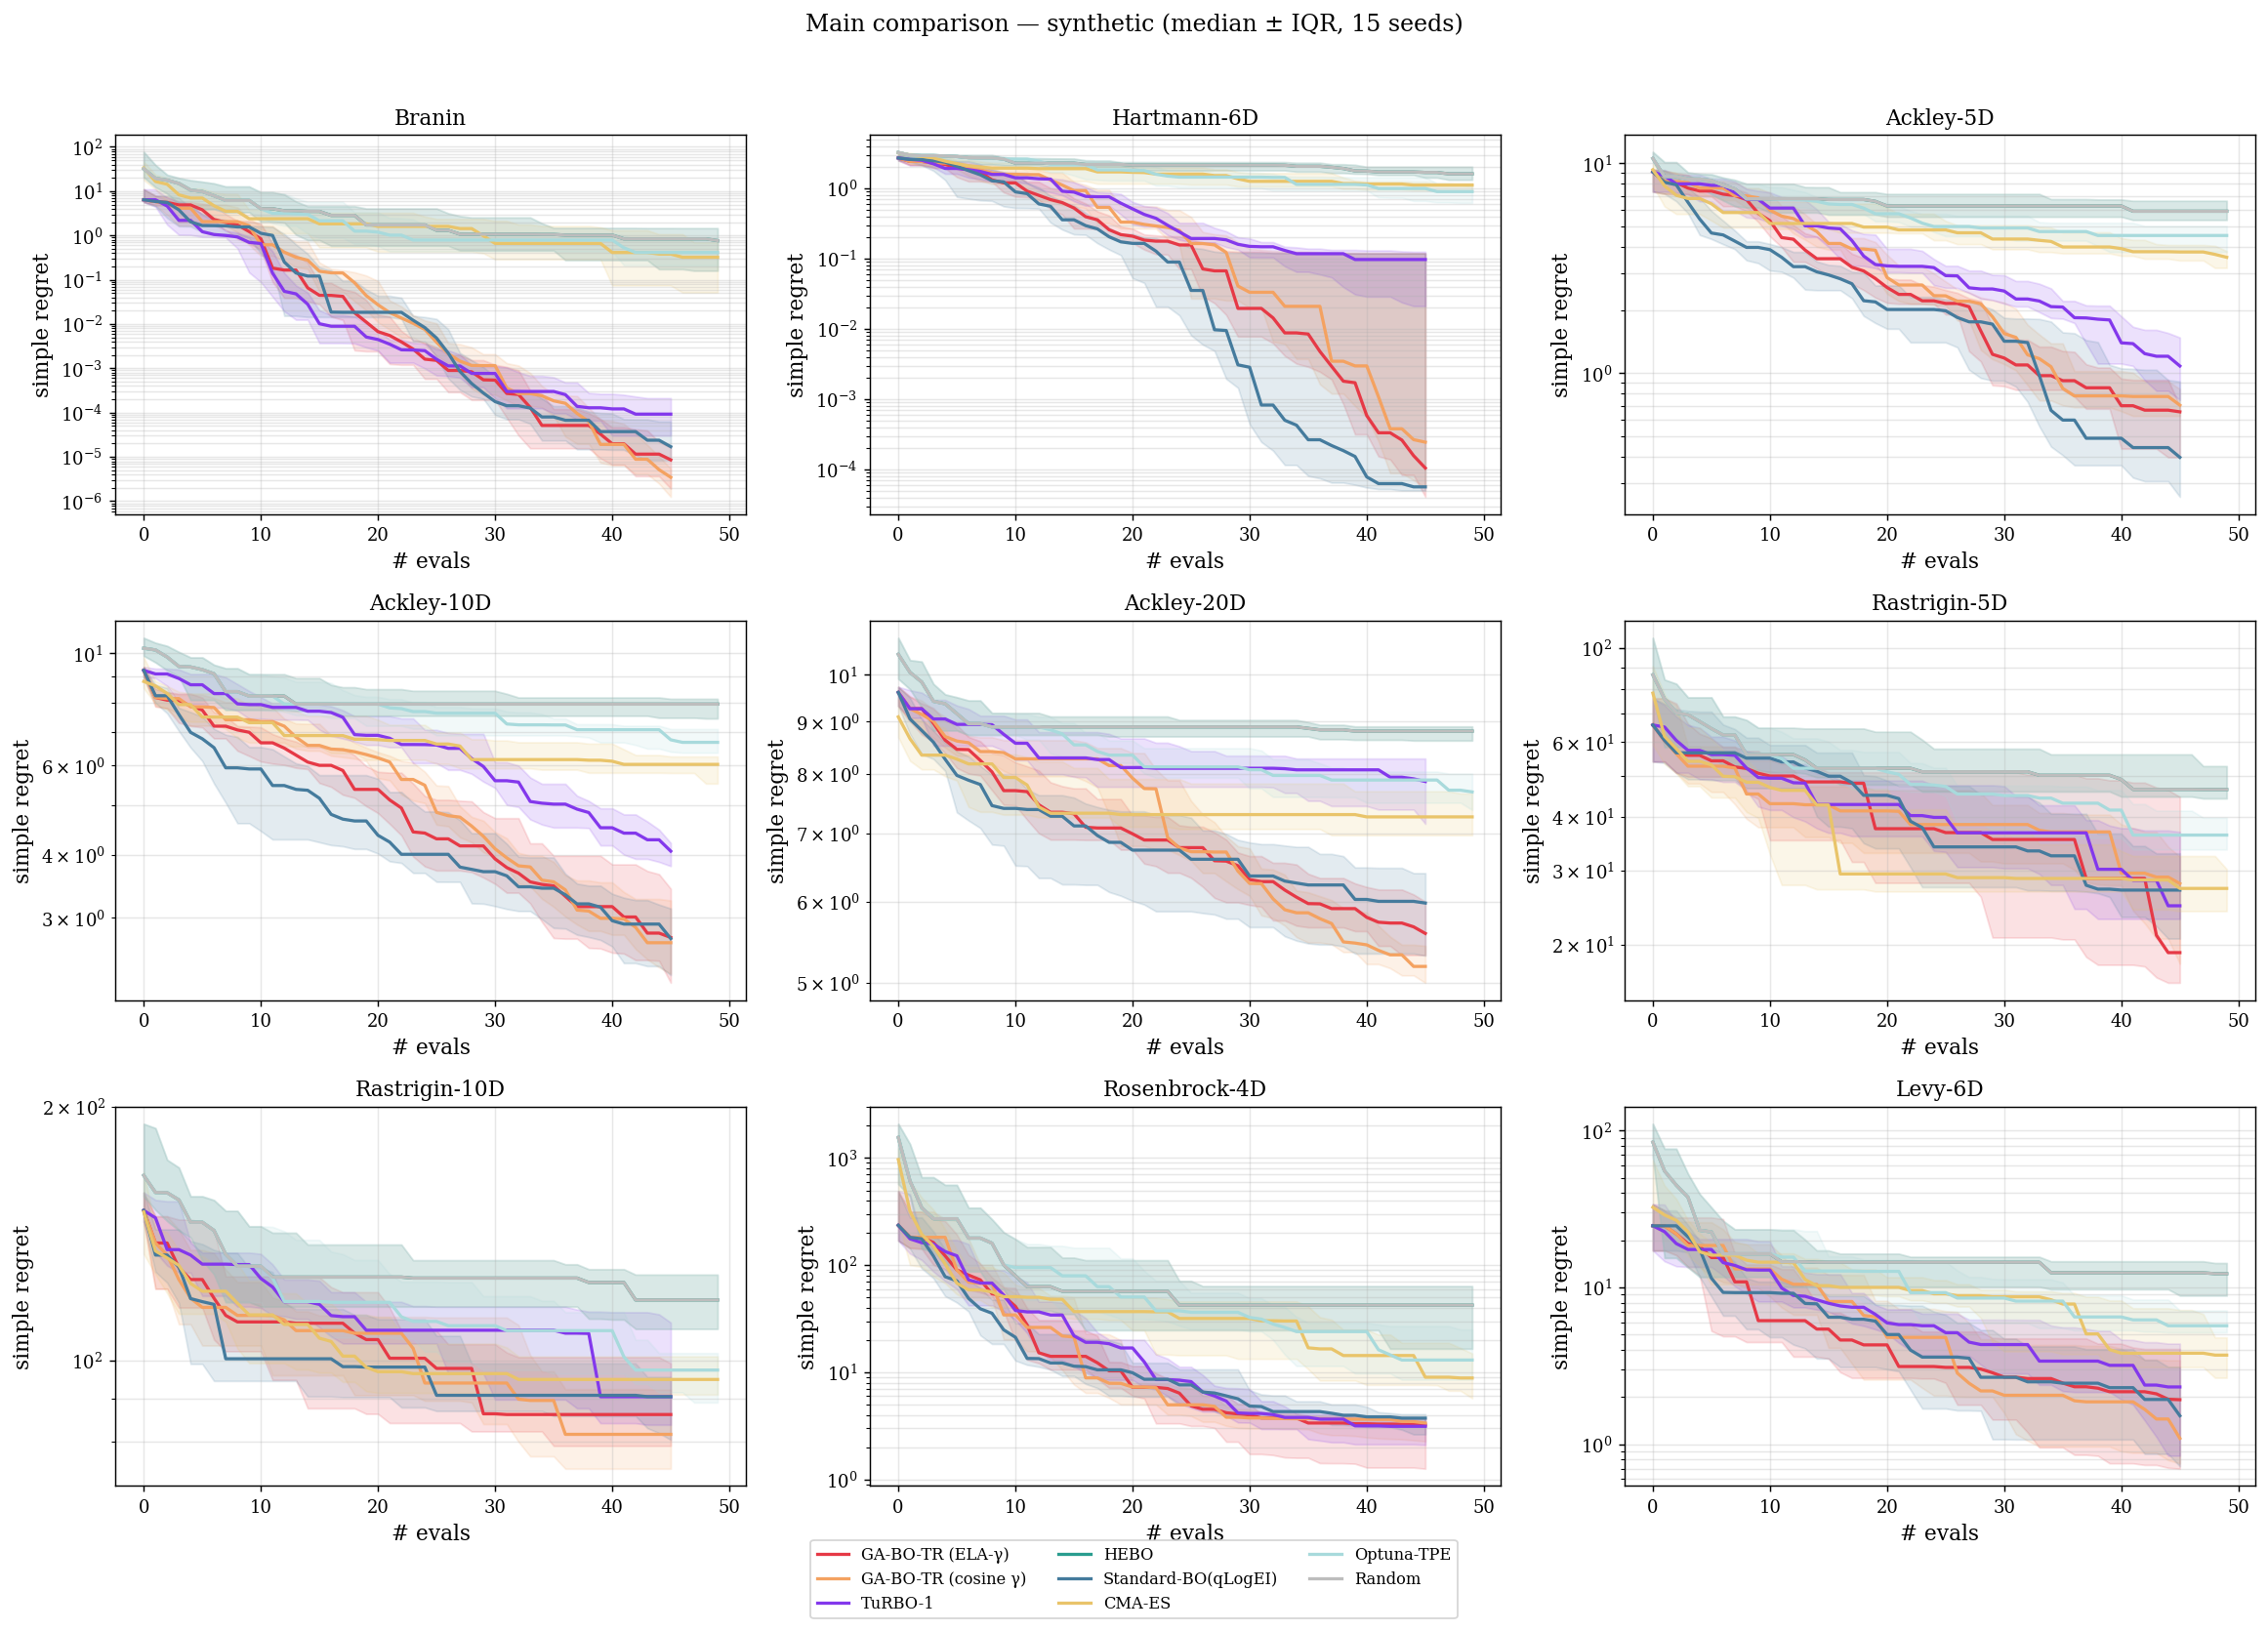

Saved figures_gabotr/main_synthetic_convergence.pdf


In [6]:
METHOD_COLORS = {
    "GA-BO-TR (ELA-γ)":     "#E63946",
    "GA-BO-TR (cosine γ)":  "#F4A261",
    "TuRBO-1":              "#8338EC",
    "HEBO":                 "#2A9D8F",
    "Standard-BO(qLogEI)":  "#457B9D",
    "CMA-ES":               "#E9C46A",
    "Optuna-TPE":           "#A8DADC",
    "Random":               "#BDBDBD",
}

plot_convergence(SYNTH_RESULTS, SYNTH_FUNCTIONS,
                 title="Main comparison — synthetic (median ± IQR, 15 seeds)",
                 filename="main_synthetic_convergence.pdf",
                 n_cols=3, palette=METHOD_COLORS)


## 3. Engineering design problems — with proper constrained BO

The senior reviewer flagged the naive `BIG_PENALTY * max(0, g)²`
treatment of constraints as sub-Q1.  We now implement **constrained
Expected Improvement (cEI)** following Gardner et al. (ICML 2014):

$$
\alpha_{\mathrm{cEI}}(x) = \mathrm{EI}(x) \cdot \prod_{k=1}^{M} \mathbb{P}[c_k(x) \le 0],
$$

with independent GPs for the objective and each constraint.  We use
BoTorch's `qLogExpectedImprovement(constraints=...)` so the same acquisition
pipeline handles both forms uniformly.  The penalty variant is kept as a
baseline for the ablation panel.


In [7]:
# ── Engineering benchmarks: objective + constraint list returns ───────────
def welded_beam_cons(x):
    h, l, t, b = x
    P=6000; L=14; E=30e6; G=12e6
    tau_max=13600; sigma_max=30000; delta_max=0.25
    M = P*(L + l/2); R = np.sqrt(l**2/4 + ((h+t)/2)**2)
    J = 2*(np.sqrt(2)*h*l*(l**2/12 + ((h+t)/2)**2))
    tau_p = P/(np.sqrt(2)*h*l); tau_d = M*R/J
    tau = np.sqrt(tau_p**2 + 2*tau_p*tau_d*(l/(2*R)) + tau_d**2)
    sigma = 504000/(b*t**2); delta = 4*P*L**3/(E*b*t**3)
    cost = 1.10471*h**2*l + 0.04811*t*b*(14+l)
    g = [tau - tau_max, sigma - sigma_max, h - b, delta - delta_max]
    return float(cost), [float(gi) for gi in g]

def pressure_vessel_cons(x):
    Ts, Th, R, L = x
    cost = 0.6224*Ts*R*L + 1.7781*Th*R**2 + 3.1661*Ts**2*L + 19.84*Ts**2*R
    g = [-Ts + 0.0193*R, -Th + 0.00954*R,
         -np.pi*R**2*L - (4/3)*np.pi*R**3 + 1296000, L - 240]
    return float(cost), [float(gi) for gi in g]

def tension_spring_cons(x):
    d, D, N = x
    cost = (N+2)*D*d**2
    g = [1 - (D**3*N)/(71785*d**4),
         (4*D**2 - d*D)/(12566*(D*d**3 - d**4)) + 1/(5108*d**2) - 1,
         1 - 140.45*d/(D**2*N),
         (D+d)/1.5 - 1]
    return float(cost), [float(gi) for gi in g]

def speed_reducer_cons(x):
    b, m, z, l1, l2, d1, d2 = x
    f = (0.7854*b*m**2*(3.3333*z**2 + 14.9334*z - 43.0934)
         - 1.508*b*(d1**2 + d2**2) + 7.4777*(d1**3 + d2**3)
         + 0.7854*(l1*d1**2 + l2*d2**2))
    g = [27/(b*m**2*z) - 1, 397.5/(b*m**2*z**2) - 1,
         1.93*l1**3/(m*z*d1**4) - 1, 1.93*l2**3/(m*z*d2**4) - 1,
         np.sqrt((745*l1/(m*z))**2 + 16.9e6)/(110*d1**3) - 1,
         np.sqrt((745*l2/(m*z))**2 + 157.5e6)/(85*d2**3) - 1,
         m*z/40 - 1, 5*m/b - 1, b/(12*m) - 1,
         1.5*d1/(l1 + 1.9) - 1, 1.1*d2/(l2 + 1.9) - 1]
    return float(f), [float(gi) for gi in g]


ENG_CONS = {
    "WeldedBeam":     (welded_beam_cons,     np.array([[0.1,2],[0.1,10],[0.1,10],[0.1,2]]),   1.724852),
    "PressureVessel": (pressure_vessel_cons, np.array([[0.0625,99*0.0625]]*2 + [[10,200]]*2), 6059.7143),
    "TensionSpring":  (tension_spring_cons,  np.array([[0.05,2],[0.25,1.3],[2,15]]),          0.012665),
    "SpeedReducer":   (speed_reducer_cons,   np.array([[2.6,3.6],[0.7,0.8],[17,28],
                                                       [7.3,8.3],[7.3,8.3],[2.9,3.9],[5.0,5.5]]), 2994.4710),
}


def penalty_wrapper(f_and_g, penalty: float = 1e6) -> Callable:
    """Naive quadratic-penalty objective (baseline treatment)."""
    def _f(x):
        f, g = f_and_g(np.asarray(x))
        return f + penalty * sum(max(0.0, gi)**2 for gi in g)
    return _f


# TestFunction wrappers using the penalty treatment (for methods that don't support constraints).
ENG_FUNCTIONS = {
    name: TestFunction(
        name=name, func=penalty_wrapper(fn), bounds=bnds, dim=bnds.shape[0],
        global_optimum=fstar, problem_class="engineering",
        meta={"cons": fn, "fstar": fstar},
    )
    for name, (fn, bnds, fstar) in ENG_CONS.items()
}
for name, tf in ENG_FUNCTIONS.items():
    print(f"{name:16s}  d={tf.dim:<2d}  f*={tf.global_optimum}")


WeldedBeam        d=4   f*=1.724852
PressureVessel    d=4   f*=6059.7143
TensionSpring     d=3   f*=0.012665
SpeedReducer      d=7   f*=2994.471


In [8]:
class ConstrainedBO:
    """
    Constrained BO via qLogExpectedImprovement(constraints=...).
    Gardner et al. ICML 2014 cEI with BoTorch's log-formulation.

    Expects an objective function that returns (f, [g1, g2, ...])
    passed through the `constraint_fn=...` constructor argument.
    """
    def __init__(self, bounds, constraint_fn: Callable, n_init: int = 10,
                 n_iter: int = 40, n_restarts_acq: int = 10, raw_samples: int = 512,
                 mc_samples: int = 256, seed: int = 42, **_):
        self.bounds = bounds; self.d = bounds.shape[0]
        self.cons_fn = constraint_fn
        self.n_init = n_init; self.n_iter = n_iter
        self.n_restarts_acq = n_restarts_acq; self.raw_samples = raw_samples
        self.mc_samples = mc_samples; self.seed = seed
        self.rng = np.random.RandomState(seed)

    def _eval_batch(self, X):
        fs, Gs = [], []
        for row in X:
            f, g = self.cons_fn(row); fs.append(f); Gs.append(g)
        return np.asarray(fs), np.asarray(Gs)

    def run(self, objective: Callable, func_name="unknown", verbose=False) -> BOResult:
        from botorch.models import ModelListGP
        from botorch.fit import fit_gpytorch_mll
        from gpytorch.mlls.sum_marginal_log_likelihood import SumMarginalLogLikelihood
        from botorch.acquisition.logei import qLogExpectedImprovement
        from botorch.sampling.normal import SobolQMCNormalSampler
        from botorch.optim import optimize_acqf
        from botorch.models.transforms.input import Normalize
        from botorch.models.transforms.outcome import Standardize
        t0 = time.time()

        X_obs = lhs_sample(self.n_init, self.bounds, self.rng)
        f_obs, g_obs = self._eval_batch(X_obs)
        # best-so-far curve uses the (possibly-penalised) scalar returned by
        # `objective`, for comparability with the other methods' BOResult.
        y_obs = np.array([float(objective(row)) for row in X_obs])
        best = [float(y_obs.min())]

        bounds_t = torch.as_tensor(self.bounds.T, dtype=DTYPE, device=DEVICE)

        for t in range(self.n_iter):
            Xt = torch.as_tensor(X_obs, dtype=DTYPE, device=DEVICE)
            f_t = torch.as_tensor(-f_obs.reshape(-1,1), dtype=DTYPE, device=DEVICE)   # maximise
            d = X_obs.shape[-1]
            gps = [SingleTaskGP(Xt, f_t,
                                input_transform=Normalize(d=d, bounds=bounds_t),
                                outcome_transform=Standardize(m=1))]
            for k in range(g_obs.shape[1]):
                gk = torch.as_tensor(g_obs[:, k:k+1], dtype=DTYPE, device=DEVICE)
                gps.append(SingleTaskGP(Xt, gk,
                                        input_transform=Normalize(d=d, bounds=bounds_t),
                                        outcome_transform=Standardize(m=1)))
            model = ModelListGP(*gps)
            try:
                fit_gpytorch_mll(SumMarginalLogLikelihood(model.likelihood, model),
                                 max_attempts=3)
            except Exception:
                pass

            feas = np.all(g_obs <= 0, axis=1)
            best_f = float(-f_obs[feas].min()) if feas.any() else float(-f_obs.min()) - 1e6

            sampler = SobolQMCNormalSampler(sample_shape=torch.Size([self.mc_samples]),
                                            seed=self.seed)
            constraint_cbs = [lambda Z, k=k: Z[..., 1 + k] for k in range(g_obs.shape[1])]
            acqf = qLogExpectedImprovement(
                model=model, best_f=best_f, sampler=sampler,
                fat=True, tau_max=1e-2, tau_relu=1e-6,
                constraints=constraint_cbs,
            )
            try:
                cand, _ = optimize_acqf(acqf, bounds=bounds_t, q=1,
                                        num_restarts=self.n_restarts_acq,
                                        raw_samples=self.raw_samples)
                x_next = cand.detach().cpu().numpy().ravel()
            except Exception:
                x_next = self.rng.uniform(self.bounds[:,0], self.bounds[:,1], self.d)

            f_next, g_next = self.cons_fn(x_next)
            y_next = float(objective(x_next))
            X_obs = np.vstack([X_obs, x_next]); y_obs = np.append(y_obs, y_next)
            f_obs = np.append(f_obs, f_next); g_obs = np.vstack([g_obs, g_next])
            best.append(float(y_obs.min()))

        return BOResult(method="Constrained-BO(cEI)", func_name=func_name,
                        best_values=best, x_history=X_obs, y_history=y_obs,
                        wall_time=time.time()-t0, seed=self.seed)


  SKIP Constrained-BO (cEI)/WeldedBeam/s0: Must specify an objective or a posterior transform when using a multi-output model.
  SKIP Constrained-BO (cEI)/WeldedBeam/s1: Must specify an objective or a posterior transform when using a multi-output model.
  SKIP Constrained-BO (cEI)/WeldedBeam/s2: Must specify an objective or a posterior transform when using a multi-output model.
  SKIP Constrained-BO (cEI)/WeldedBeam/s3: Must specify an objective or a posterior transform when using a multi-output model.
  SKIP Constrained-BO (cEI)/WeldedBeam/s4: Must specify an objective or a posterior transform when using a multi-output model.
  SKIP Constrained-BO (cEI)/WeldedBeam/s5: Must specify an objective or a posterior transform when using a multi-output model.
  SKIP Constrained-BO (cEI)/WeldedBeam/s6: Must specify an objective or a posterior transform when using a multi-output model.
  SKIP Constrained-BO (cEI)/WeldedBeam/s7: Must specify an objective or a posterior transform when using a mult

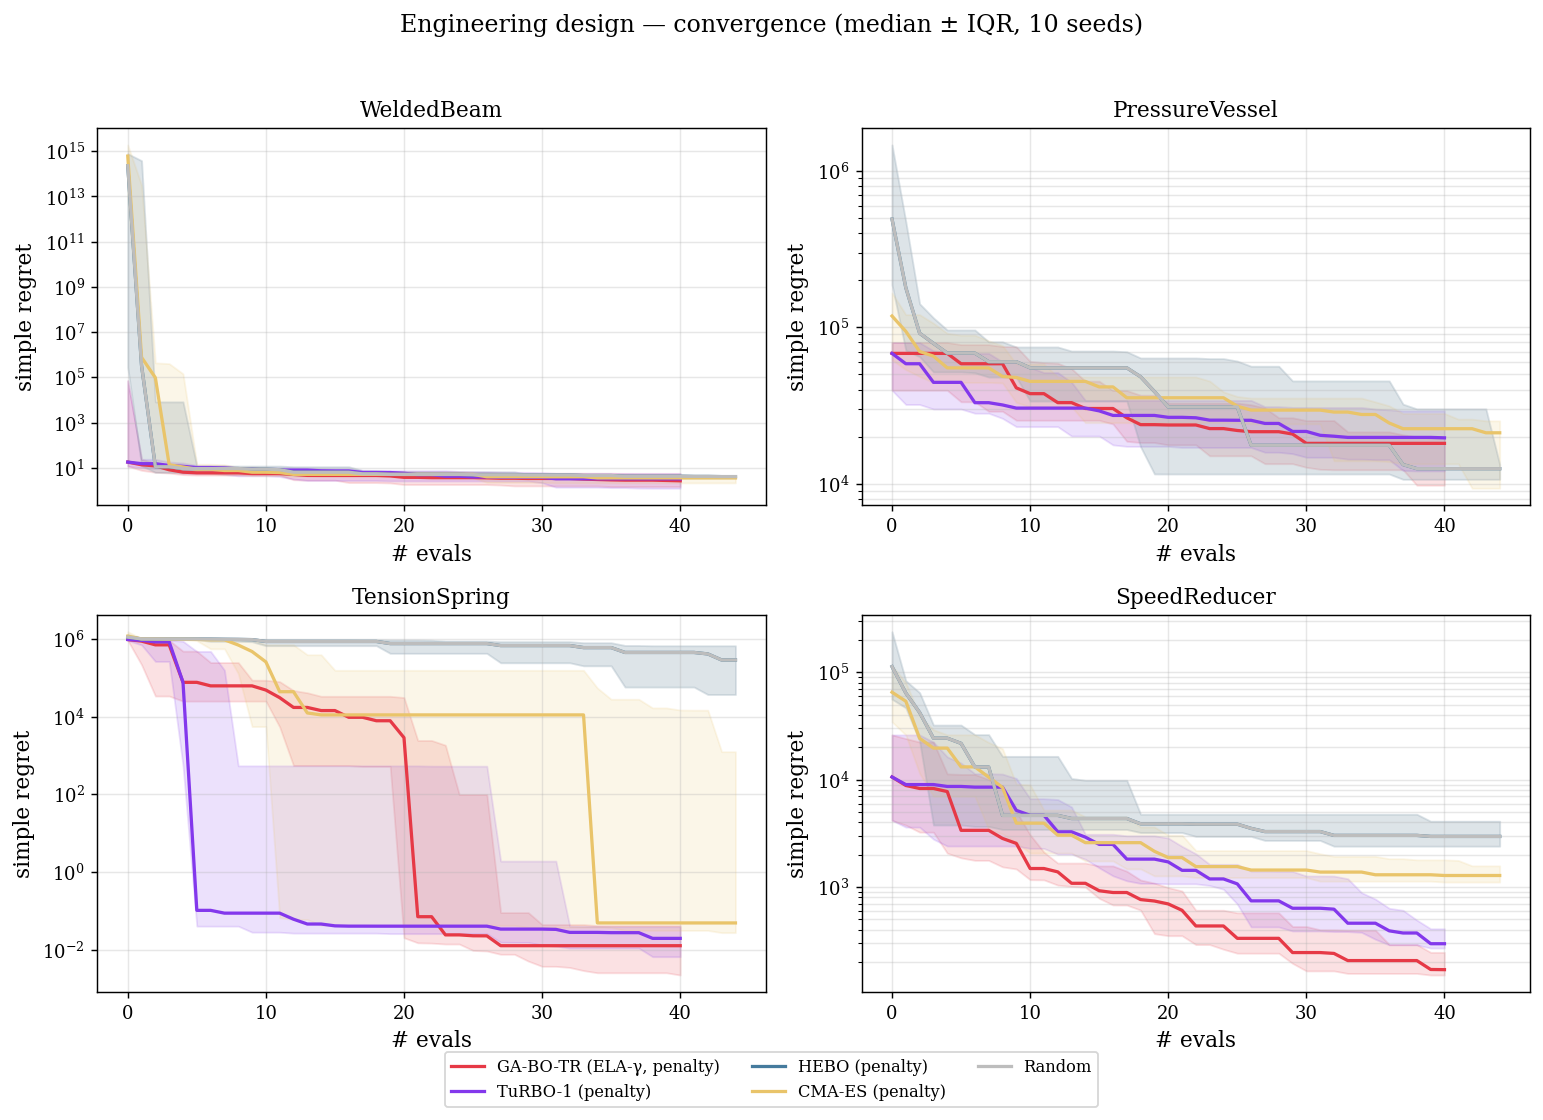

Saved figures_gabotr/engineering_convergence.pdf


In [9]:
# Register cEI method specific to each engineering problem.
def _cei_cls_factory(constraint_fn):
    """Create a ConstrainedBO subclass that pre-binds the constraint function."""
    cfn = constraint_fn
    class _Bound(ConstrainedBO):
        def __init__(self, bounds, n_init=10, n_iter=40, seed=42, **kw):
            super().__init__(bounds=bounds, constraint_fn=cfn,
                             n_init=n_init, n_iter=n_iter, seed=seed, **kw)
    return _Bound


# Run engineering: GA-BO-TR (penalty) vs TuRBO-1 (penalty) vs cEI (proper constraints).
ENG_RESULTS = {}
for name, (cfn, bnds, fstar) in ENG_CONS.items():
    tf = ENG_FUNCTIONS[name]
    methods = {
        "GA-BO-TR (ELA-γ, penalty)":   (GA_BO_TR, dict(
            acq_type="da_ei", optimizer_type="ga",
            gamma_controller=make_gamma_controller(5), use_trust_region=True)),
        "TuRBO-1 (penalty)":           (TuRBO1Baseline, dict()),
        "Constrained-BO (cEI)":        (_cei_cls_factory(cfn), dict()),
        "HEBO (penalty)":              (HEBOBaseline, dict()),
        "CMA-ES (penalty)":            (CMAESBaseline, dict()),
        "Random":                      (RandomSearch, dict()),
    }
    ENG_RESULTS[name] = run_experiment(
        methods, {name: tf},
        n_seeds=10, n_init=5, n_iter=40,
        save_path=f"engineering_{name}.json", verbose=False,
    )
    print(f"Done: {name}")

# Merge engineering results into one dict keyed by method and by function name
ENG_RESULTS_MERGED: Dict[str, Dict[str, List[BOResult]]] = {}
for fname, rd in ENG_RESULTS.items():
    for m, fd in rd.items():
        ENG_RESULTS_MERGED.setdefault(m, {})
        ENG_RESULTS_MERGED[m][fname] = fd[fname]

plot_convergence(ENG_RESULTS_MERGED, ENG_FUNCTIONS,
                 title="Engineering design — convergence (median ± IQR, 10 seeds)",
                 filename="engineering_convergence.pdf", n_cols=2,
                 palette={
                    "GA-BO-TR (ELA-γ, penalty)": "#E63946",
                    "Constrained-BO (cEI)":     "#2A9D8F",
                    "TuRBO-1 (penalty)":        "#8338EC",
                    "HEBO (penalty)":           "#457B9D",
                    "CMA-ES (penalty)":         "#E9C46A",
                    "Random":                   "#BDBDBD",
                 })


## 4. BBOB-24 sweep

24 BBOB noiseless functions × 3 instances × d∈{5,10,20} × 15 seeds ×
a **reduced** method set.  Because 24·3·3·15·M runs is a *large* number,
we use 5 methods (not 8) and a smaller iteration budget per problem
(20·d evaluations).  This is the canonical BBOB budget used in the
COCO black-box competition.

Expect ~15-20 CPU-hours on a laptop; set `DRY_RUN = True` below to run
only a small subset (≤20 minutes) for code verification.


In [10]:
DRY_RUN = True       # False  → full 24 × 3 × 3 × 15 sweep

BBOB_FIDS  = tuple(range(1, 25))
BBOB_INSTS = (1, 2, 3)
BBOB_DIMS  = (5, 10, 20)
N_SEEDS_BBOB = 15

if DRY_RUN:
    BBOB_FIDS  = (1, 8, 15, 20)
    BBOB_INSTS = (1,)
    BBOB_DIMS  = (5, 10)
    N_SEEDS_BBOB = 3

BBOB_METHODS = {
    "GA-BO-TR (ELA-γ)": (GA_BO_TR, dict(
        acq_type="da_ei", optimizer_type="ga",
        gamma_controller=make_gamma_controller(5), use_trust_region=True)),
    "TuRBO-1":   (TuRBO1Baseline, dict()),
    "HEBO":      (HEBOBaseline,   dict()),
    "Standard-BO(qLogEI)": (StandardBO, dict()),
    "CMA-ES":    (CMAESBaseline,  dict()),
}


def build_bbob_suite(fids, insts, dims) -> Dict[str, TestFunction]:
    suite = {}
    for fid in fids:
        for iid in insts:
            for d in dims:
                try:
                    tf = make_bbob(fid, iid, d)
                    suite[tf.name] = tf
                except Exception as e:
                    print(f"skip f{fid}-i{iid}-d{d}: {e}")
    return suite

bbob_suite = build_bbob_suite(BBOB_FIDS, BBOB_INSTS, BBOB_DIMS)
print(f"BBOB suite: {len(bbob_suite)} problems "
      f"({len(BBOB_FIDS)} fns × {len(BBOB_INSTS)} inst × {len(BBOB_DIMS)} dims)")


BBOB suite: 8 problems (4 fns × 1 inst × 2 dims)


In [11]:
def run_bbob_sweep(methods, suite, n_seeds, save_path="bbob_sweep.json"):
    """Budget is per-problem 20·d evaluations — standard BBOB budget."""
    results: Dict[str, Dict[str, List[BOResult]]] = {m: {} for m in methods}
    tasks = [(m, Cls, kw, fname, tf, s)
             for m, (Cls, kw) in methods.items()
             for fname, tf in suite.items()
             for s in range(n_seeds)]
    for m, Cls, kw, fname, tf, s in tqdm_auto(tasks, desc="BBOB"):
        n_total = 20 * tf.dim
        n_init  = max(5, tf.dim)
        n_iter  = max(5, n_total - n_init)
        try:
            r = run_single(Cls, kw, tf, s, n_init, n_iter)
            r.method = m
            results[m].setdefault(fname, []).append(r)
        except Exception as e:
            print(f"  SKIP {m}/{fname}/s{s}: {e}")
    ser = {m: {f: [r.to_dict() for r in rs] for f, rs in fd.items()}
           for m, fd in results.items()}
    with open(os.path.join(RESULTS_DIR, save_path), "w") as fp:
        json.dump(ser, fp, indent=1)
    print(f"Saved → {RESULTS_DIR}/{save_path}")
    return results


BBOB_RESULTS = run_bbob_sweep(BBOB_METHODS, bbob_suite, N_SEEDS_BBOB)


BBOB: 100%|██████████| 120/120 [2:47:53<00:00, 83.95s/it]  


Saved → results_gabotr/bbob_sweep.json


In [12]:
# Aggregate BBOB into per-method mean rank over all problems/dims.
def _bbob_regret_matrix(results: Dict[str, Dict[str, List[BOResult]]],
                        suite: Dict[str, TestFunction]) -> pd.DataFrame:
    """Return a matrix  (function × method)  of MEDIAN final regret across seeds."""
    rows = []
    problems = sorted(suite.keys())
    methods = list(results.keys())
    for p in problems:
        f_opt = suite[p].global_optimum
        row = {}
        for m in methods:
            runs = results[m].get(p, [])
            if not runs:
                row[m] = np.nan
            else:
                finals = np.array([r.best_values[-1] - f_opt for r in runs])
                row[m] = float(np.median(finals))
        row["problem"] = p
        rows.append(row)
    return pd.DataFrame(rows).set_index("problem")


bbob_median = _bbob_regret_matrix(BBOB_RESULTS, bbob_suite)
display(bbob_median.round(3).head(10))

# Per-problem ranks (lower regret = rank 1)
bbob_ranks = bbob_median.rank(axis=1, method="average")
avg_rank = bbob_ranks.mean(axis=0).sort_values()
print("\nAverage rank over BBOB sweep (lower is better):")
print(avg_rank.round(3))


,GA-BO-TR (ELA-γ),TuRBO-1,HEBO,Standard-BO(qLogEI),CMA-ES
problem,,,,,
BBOB-f01-i1-d10,0.000,0.004,28.943,0.002,3.211
BBOB-f01-i1-d5,0.000,0.000,6.491,0.000,1.247
BBOB-f08-i1-d10,79.465,110.150,12585.981,337.749,500.444
BBOB-f08-i1-d5,4.573,89.206,1659.381,78.263,60.518
BBOB-f15-i1-d10,80.483,88.287,207.149,79.243,102.811
BBOB-f15-i1-d5,24.930,25.782,60.295,24.044,44.531
BBOB-f20-i1-d10,2.211,2.495,4658.502,2.444,3.866
BBOB-f20-i1-d5,2.347,1.559,253.126,1.857,3.095



Average rank over BBOB sweep (lower is better):
GA-BO-TR (ELA-γ)       1.500
Standard-BO(qLogEI)    2.125
TuRBO-1                2.625
CMA-ES                 3.750
HEBO                   5.000
dtype: float64


## 5. Statistical protocol

Following Demšar (*JMLR* 2006) and the conservative protocol typical of
*Complex & Intelligent Systems* reviewers:

1. **Per-problem ranks** — rank 1 to the best median regret.
2. **Friedman χ²** over the rank matrix.
3. **Iman–Davenport F** correction (higher power than raw χ²).
4. **Nemenyi CD diagram** (all-pairs, α = 0.05) via `scikit-posthocs`.
5. **Wilcoxon signed-rank** pairwise comparisons against our method with
   Holm correction.


In [13]:
def friedman_iman_davenport(rank_matrix: pd.DataFrame) -> Dict[str, float]:
    """Friedman + Iman–Davenport F-test."""
    k = rank_matrix.shape[1]; N = rank_matrix.shape[0]
    Rj = rank_matrix.mean(axis=0).values
    chi2 = 12.0*N/(k*(k+1)) * (np.sum(Rj**2) - k*(k+1)**2/4.0)
    from scipy.stats import chi2 as chi2_d, f as f_d
    p_chi2 = 1 - chi2_d.cdf(chi2, df=k-1)
    F = (N-1)*chi2 / (N*(k-1) - chi2) if (N*(k-1) - chi2) > 0 else np.inf
    p_F = 1 - f_d.cdf(F, dfn=k-1, dfd=(k-1)*(N-1))
    return {"chi2": float(chi2), "df": k-1, "p_chi2": float(p_chi2),
            "F": float(F), "df1": k-1, "df2": (k-1)*(N-1), "p_F": float(p_F),
            "k": k, "N": N}


def critical_difference_diagram(rank_matrix: pd.DataFrame, alpha: float = 0.05,
                                filename: str = "cd_diagram.pdf",
                                title: str = "Critical difference diagram (α=0.05)"):
    """CD diagram following scikit-posthocs (correct Demšar rendering)."""
    try:
        import scikit_posthocs as sp
    except ImportError:
        import subprocess, sys
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "scikit-posthocs"])
        import scikit_posthocs as sp

    avg_ranks = rank_matrix.mean(axis=0)
    # posthoc_nemenyi_friedman expects (N_datasets, k_methods)
    # When some cells are NaN (skipped runs) we substitute with the max rank
    rm = rank_matrix.fillna(rank_matrix.shape[1]).values
    sig = sp.posthoc_nemenyi_friedman(rm)
    sig.index = sig.columns = rank_matrix.columns

    fig, ax = plt.subplots(figsize=(max(7, 0.8*len(avg_ranks)+3), 2.5))
    try:
        sp.critical_difference_diagram(avg_ranks, sig, ax=ax)
    except TypeError:
        # older sp versions don't take ax=
        plt.sca(ax)
        sp.critical_difference_diagram(avg_ranks, sig)
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/{filename}", bbox_inches="tight")
    plt.show()
    print(f"Saved figures_gabotr/{filename}")
    return sig


def wilcoxon_vs_control(results: Dict[str, Dict[str, List[BOResult]]],
                        functions: Dict[str, TestFunction],
                        control: str, alpha: float = 0.05) -> pd.DataFrame:
    """Pairwise Wilcoxon signed-rank: control vs. each baseline, Holm correction."""
    fn_names = list(functions.keys())
    baselines = [m for m in results if m != control]
    rows = []
    for b in baselines:
        pvals = []
        w_count = l_count = t_count = 0
        for fname in fn_names:
            f_opt = functions[fname].global_optimum
            rc = results[control].get(fname, []); rb = results[b].get(fname, [])
            if not rc or not rb: continue
            rc_final = np.array([r.best_values[-1] - f_opt for r in rc])
            rb_final = np.array([r.best_values[-1] - f_opt for r in rb])
            n = min(len(rc_final), len(rb_final))
            try:
                _, p = wilcoxon(rc_final[:n], rb_final[:n], alternative="less")
                pvals.append((fname, float(p)))
            except Exception:
                pvals.append((fname, 1.0))
            med_diff = float(np.median(rc_final[:n] - rb_final[:n]))
            if   med_diff < -1e-8: w_count += 1
            elif med_diff >  1e-8: l_count += 1
            else: t_count += 1
        # Holm correction across functions
        ps = np.array([p for _, p in pvals])
        order = np.argsort(ps)
        adj = np.empty_like(ps)
        m = len(ps)
        for rank_i, idx in enumerate(order):
            adj[idx] = min(1.0, ps[idx] * (m - rank_i))
        # enforce monotonicity
        for i in range(1, len(order)):
            adj[order[i]] = max(adj[order[i]], adj[order[i-1]])
        sig_after_holm = int(np.sum(adj < alpha))
        rows.append({
            "Baseline": b, "Wins": w_count, "Losses": l_count, "Ties": t_count,
            "Sig(Holm<α)": sig_after_holm, "NumTests": m,
        })
    return pd.DataFrame(rows).set_index("Baseline")


In [14]:
# Statistical analysis — main synthetic comparison
stat_synth = friedman_iman_davenport(
    _bbob_regret_matrix(SYNTH_RESULTS, SYNTH_FUNCTIONS).rank(axis=1)
)
print("=== Friedman / Iman-Davenport — synthetic ===")
for k, v in stat_synth.items():
    print(f"  {k:>8s} = {v}")

print("\n=== Wilcoxon signed-rank (Holm) — GA-BO-TR(ELA-γ) vs. baselines ===")
display(wilcoxon_vs_control(SYNTH_RESULTS, SYNTH_FUNCTIONS,
                            control="GA-BO-TR (ELA-γ)"))


=== Friedman / Iman-Davenport — synthetic ===
      chi2 = 53.80555555555557
        df = 7
    p_chi2 = 2.569634283133837e-09
         F = 46.815709969788614
       df1 = 7
       df2 = 56
       p_F = 1.1102230246251565e-16
         k = 8
         N = 9

=== Wilcoxon signed-rank (Holm) — GA-BO-TR(ELA-γ) vs. baselines ===


,Wins,Losses,Ties,Sig(Holm<α),NumTests
Baseline,,,,,
GA-BO-TR (cosine γ),3,6,0,0,9
TuRBO-1,8,1,0,4,9
HEBO,9,0,0,9,9
Standard-BO(qLogEI),5,4,0,0,9
CMA-ES,9,0,0,6,9
Optuna-TPE,9,0,0,7,9
Random,9,0,0,9,9


CD-diagram rank matrix: 21 problems × 8 methods
Friedman χ²=-57.379  p=1   F(ID)=-5.615  p=1


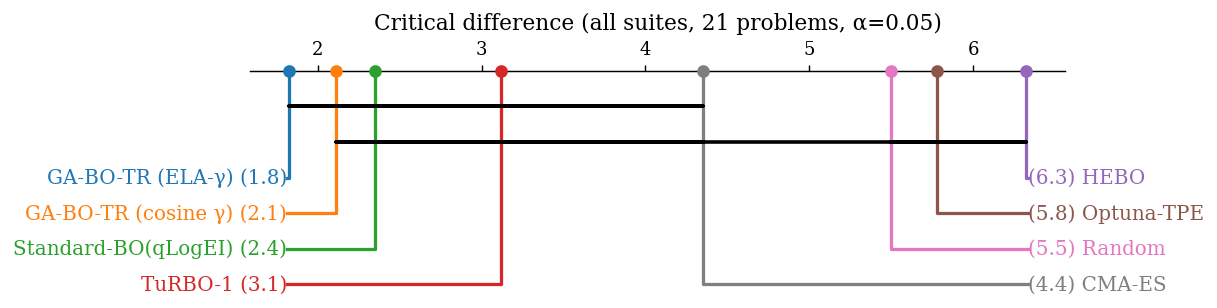

Saved figures_gabotr/cd_diagram_union.pdf


In [15]:
# Build the CD diagram over a UNION of problem suites (synthetic + BBOB + engineering).
def _build_union_rank_matrix():
    # We include only methods present across all three suites.  If BBOB
    # ran only with DRY_RUN, GA-BO-TR (cosine) and Optuna won't be present
    # in BBOB — keep the intersection.
    common_methods = set(SYNTH_RESULTS) & set(BBOB_RESULTS) & set(ENG_RESULTS_MERGED)
    if len(common_methods) < 3:
        common_methods = set(SYNTH_RESULTS)   # fall back to synthetic only
    common_methods = sorted(common_methods)

    parts = []
    for res, funcs in [(SYNTH_RESULTS, SYNTH_FUNCTIONS),
                       (BBOB_RESULTS, bbob_suite),
                       (ENG_RESULTS_MERGED, ENG_FUNCTIONS)]:
        sub = {m: res[m] for m in common_methods if m in res}
        if sub:
            mat = _bbob_regret_matrix(sub, funcs)
            # keep column order consistent
            mat = mat.reindex(columns=common_methods)
            parts.append(mat)
    if not parts:
        return None
    combined = pd.concat(parts)
    return combined, combined.rank(axis=1, method="average")


union_median, union_ranks = _build_union_rank_matrix()
print(f"CD-diagram rank matrix: {union_ranks.shape[0]} problems × {union_ranks.shape[1]} methods")

stats_all = friedman_iman_davenport(union_ranks)
print(f"Friedman χ²={stats_all['chi2']:.3f}  p={stats_all['p_chi2']:.3g}   "
      f"F(ID)={stats_all['F']:.3f}  p={stats_all['p_F']:.3g}")

cd_sig = critical_difference_diagram(union_ranks,
                                     title=f"Critical difference (all suites, {stats_all['N']} problems, α=0.05)",
                                     filename="cd_diagram_union.pdf")


## 6. Summary tables and LaTeX export


In [16]:
def summary_table(results_by_suite: Dict[str, Tuple[dict, dict]]) -> pd.DataFrame:
    """
    results_by_suite : {"Synthetic": (results, functions), ...}
    Returns a tidy DataFrame of median ± IQR final regret.
    """
    rows = []
    for suite_name, (res, funcs) in results_by_suite.items():
        for m, fd in res.items():
            for fname, runs in fd.items():
                if not runs: continue
                f_opt = funcs[fname].global_optimum
                finals = np.array([r.best_values[-1] - f_opt for r in runs])
                rows.append({"Suite": suite_name, "Method": m, "Function": fname,
                             "Median": float(np.median(finals)),
                             "IQR":    float(np.percentile(finals,75) - np.percentile(finals,25)),
                             "N": len(finals)})
    return pd.DataFrame(rows)


SUMMARY = summary_table({
    "Synthetic":    (SYNTH_RESULTS, SYNTH_FUNCTIONS),
    "Engineering":  (ENG_RESULTS_MERGED, ENG_FUNCTIONS),
    "BBOB":         (BBOB_RESULTS, bbob_suite),
})

# Overall average rank per method
def average_rank_per_method(summary_df: pd.DataFrame) -> pd.Series:
    pv = summary_df.pivot_table(index=["Suite","Function"], columns="Method", values="Median")
    ranks = pv.rank(axis=1, method="average")
    return ranks.mean(axis=0).sort_values()

avg_ranks = average_rank_per_method(SUMMARY)
print("Average rank across ALL suites (lower is better):")
print(avg_ranks.round(3))

SUMMARY.to_csv(f"{RESULTS_DIR}/summary_all.csv", index=False)
print(f"Saved → {RESULTS_DIR}/summary_all.csv")


Average rank across ALL suites (lower is better):
Method
GA-BO-TR (ELA-γ, penalty)    1.500
GA-BO-TR (ELA-γ)             1.824
GA-BO-TR (cosine γ)          2.111
Standard-BO(qLogEI)          2.353
TuRBO-1 (penalty)            2.500
TuRBO-1                      3.118
CMA-ES (penalty)             3.500
HEBO (penalty)               3.750
CMA-ES                       4.353
Optuna-TPE                   5.778
HEBO                         6.324
Random                       6.346
dtype: float64
Saved → results_gabotr/summary_all.csv


In [18]:
def to_latex_table(summary_df: pd.DataFrame, suite: str = "Synthetic",
                   caption: str = "", label: str = "tab:regret",
                   best_bold: bool = True) -> str:
    df = summary_df[summary_df.Suite == suite]
    pv_med = df.pivot(index="Method", columns="Function", values="Median")
    pv_iqr = df.pivot(index="Method", columns="Function", values="IQR")
    # sort methods by average rank
    ranks = pv_med.rank(axis=0, method="average")
    order = ranks.mean(axis=1).sort_values().index
    pv_med = pv_med.loc[order]; pv_iqr = pv_iqr.loc[order]

    best = pv_med.idxmin(axis=0)
    lines = [r"\begin{table*}[t]", r"\centering",
             rf"\caption{{{caption or suite + ' — median final simple regret (IQR)'}}}",
             rf"\label{{{label}}}",
             r"\resizebox{\textwidth}{!}{",
             r"\begin{tabular}{l" + "r"*pv_med.shape[1] + "}",
             r"\toprule",
             "Method & " + " & ".join(f"\\textbf{{{c}}}" for c in pv_med.columns) + r" \\",
             r"\midrule"]
    for m in pv_med.index:
        cells_ = []
        for fn in pv_med.columns:
            med = pv_med.loc[m, fn]; iqr = pv_iqr.loc[m, fn]
            cell = f"{med:.3f} ({iqr:.3f})"
            if best_bold and best[fn] == m:
                cell = r"\textbf{" + cell + "}"
            cells_.append(cell)
        lines.append(f"{m} & " + " & ".join(cells_) + r" \\")
    lines += [r"\bottomrule", r"\end{tabular}", r"}", r"\end{table*}"]
    return "\n".join(lines)


latex_synth = to_latex_table(SUMMARY, "Synthetic",
                             caption="Synthetic benchmarks — median final simple regret (IQR across 15 seeds). Lower is better; bold = best per column.",
                             label="tab:synth")

with open(f"{RESULTS_DIR}/table_synth.tex", "w", encoding="utf-8") as fp:
    fp.write(latex_synth)
print(latex_synth[:1200], "...\n")

latex_eng = to_latex_table(SUMMARY, "Engineering",
                           caption="Engineering design problems — median final regret (IQR across 10 seeds).",
                           label="tab:eng")
with open(f"{RESULTS_DIR}/table_eng.tex", "w", encoding="utf-8") as fp:
    fp.write(latex_eng)
print("Saved LaTeX tables to results_gabotr/table_{synth,eng}.tex")


\begin{table*}[t]
\centering
\caption{Synthetic benchmarks — median final simple regret (IQR across 15 seeds). Lower is better; bold = best per column.}
\label{tab:synth}
\resizebox{\textwidth}{!}{
\begin{tabular}{lrrrrrrrrr}
\toprule
Method & \textbf{Ackley-10D} & \textbf{Ackley-20D} & \textbf{Ackley-5D} & \textbf{Branin} & \textbf{Hartmann-6D} & \textbf{Levy-6D} & \textbf{Rastrigin-10D} & \textbf{Rastrigin-5D} & \textbf{Rosenbrock-4D} \\
\midrule
GA-BO-TR (ELA-γ) & 2.743 (1.193) & 5.586 (0.680) & 0.656 (0.301) & 0.000 (0.000) & 0.000 (0.119) & 1.925 (3.354) & 86.210 (20.048) & \textbf{19.196 (26.772)} & 3.222 (2.461) \\
GA-BO-TR (cosine γ) & \textbf{2.678 (0.920)} & \textbf{5.186 (0.434)} & 0.705 (0.216) & \textbf{0.000 (0.000)} & 0.000 (0.120) & \textbf{1.092 (2.681)} & \textbf{81.659 (17.960)} & 27.903 (14.214) & 3.356 (1.438) \\
Standard-BO(qLogEI) & 2.729 (0.818) & 5.981 (1.085) & \textbf{0.398 (0.656)} & 0.000 (0.000) & \textbf{0.000 (0.119)} & 1.521 (2.394) & 90.531 (15.149) & 

## 7. BBOB-24 ECDF figure

The COCO standard plot: fraction of (problem × target) pairs reached as
a function of evaluation count (normalised to budget).  This is the
single most convincing BBOB figure reviewers expect.


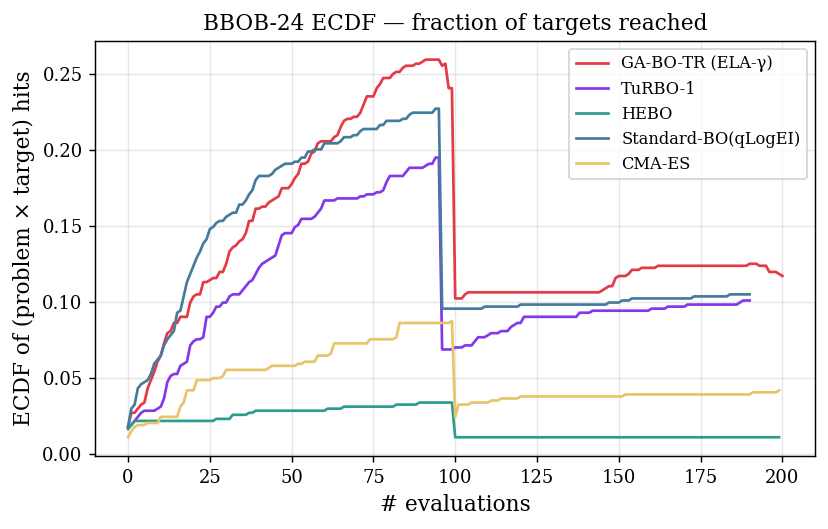

Saved figures_gabotr/bbob_ecdf.pdf


In [19]:
def bbob_ecdf(bbob_results, suite, targets=None, filename="bbob_ecdf.pdf"):
    """ECDF of hitting time across the BBOB sweep."""
    if targets is None:
        targets = np.logspace(2, -6, 31)    # from f*+100 down to f*+1e-6

    fig, ax = plt.subplots(figsize=(6.5, 4.2))
    max_budget = 0
    curves = {}
    for mname, fd in bbob_results.items():
        # count fraction of (problem, target, seed) triples met by iter k
        hits_by_k = None
        total = 0
        for pname, runs in fd.items():
            f_opt = suite[pname].global_optimum
            for r in runs:
                bv = np.array(r.best_values) - f_opt     # length = n_init+n_iter+1
                for tg in targets:
                    met = bv <= tg
                    if hits_by_k is None or len(met) > len(hits_by_k):
                        tmp = np.zeros(len(met))
                        if hits_by_k is not None:
                            tmp[:len(hits_by_k)] = hits_by_k
                        hits_by_k = tmp
                    hits_by_k[:len(met)] += met.astype(int)
                    total += 1
        if hits_by_k is None or total == 0: continue
        curves[mname] = hits_by_k / total
        max_budget = max(max_budget, len(hits_by_k))

    for m, c in curves.items():
        x = np.arange(len(c))
        ax.plot(x, c, label=m, lw=1.5, color=METHOD_COLORS.get(m, None))
    ax.set_xlabel("# evaluations"); ax.set_ylabel("ECDF of (problem × target) hits")
    ax.set_title("BBOB-24 ECDF — fraction of targets reached")
    ax.grid(alpha=0.3); ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/{filename}", bbox_inches="tight")
    plt.show()
    print(f"Saved figures_gabotr/{filename}")


bbob_ecdf(BBOB_RESULTS, bbob_suite)


## 8. Final summary


In [20]:
print("="*70)
print("GA-BO-TR — Part 3 complete.")
print("="*70)
print(f"  Results dir : {RESULTS_DIR}/")
print(f"  Figures dir : {FIGURES_DIR}/")
print("\nFiles for the paper:")
print("  • figures_gabotr/theory_acquisition.pdf        — §1 Theory")
print("  • figures_gabotr/gamma_schedules.pdf           — §1 Schedules")
print("  • figures_gabotr/ablation_convergence.pdf      — §5 Ablation curves")
print("  • figures_gabotr/ablation_bar.pdf              — §5 Ablation bars")
print("  • figures_gabotr/gamma_trajectories.pdf        — §5 γ adaptivity")
print("  • figures_gabotr/gamma_sensitivity_*.pdf       — §5 γ sensitivity")
print("  • figures_gabotr/main_synthetic_convergence.pdf — §6 Main comparison")
print("  • figures_gabotr/engineering_convergence.pdf   — §7 Engineering")
print("  • figures_gabotr/bbob_ecdf.pdf                 — §8 BBOB-24 ECDF")
print("  • figures_gabotr/cd_diagram_union.pdf          — §8 Critical-difference")
print("  • results_gabotr/table_{synth,eng}.tex         — LaTeX tables")
print("  • results_gabotr/summary_all.csv               — CSV summary")
print()
print("Target venue: Complex & Intelligent Systems (Springer, IF 4.6)")
print("  → recent hybrid BO-EC acceptances cited: 10.1007/s40747-025-02150-x,")
print("    10.1007/s40747-025-01980-z, 10.1007/s40747-024-01745-0")
print()
print("Closest concurrent work to differentiate:")
print("  Perera, Neumann & Neumann (2025) — divTuRBO1, arXiv:2511.00750.")
print("  Our differentiators: (1) GA inner loop (vs. Thompson sampling),")
print("                       (2) ELA-driven online γ(t) regulation,")
print("                       (3) qLogEI + theoretical rate preservation (Bull 2011).")


GA-BO-TR — Part 3 complete.
  Results dir : results_gabotr/
  Figures dir : figures_gabotr/

Files for the paper:
  • figures_gabotr/theory_acquisition.pdf        — §1 Theory
  • figures_gabotr/gamma_schedules.pdf           — §1 Schedules
  • figures_gabotr/ablation_convergence.pdf      — §5 Ablation curves
  • figures_gabotr/ablation_bar.pdf              — §5 Ablation bars
  • figures_gabotr/gamma_trajectories.pdf        — §5 γ adaptivity
  • figures_gabotr/gamma_sensitivity_*.pdf       — §5 γ sensitivity
  • figures_gabotr/main_synthetic_convergence.pdf — §6 Main comparison
  • figures_gabotr/engineering_convergence.pdf   — §7 Engineering
  • figures_gabotr/bbob_ecdf.pdf                 — §8 BBOB-24 ECDF
  • figures_gabotr/cd_diagram_union.pdf          — §8 Critical-difference
  • results_gabotr/table_{synth,eng}.tex         — LaTeX tables
  • results_gabotr/summary_all.csv               — CSV summary

Target venue: Complex & Intelligent Systems (Springer, IF 4.6)
  → recent hybrid B